In [2]:
# Membangun struktur dictionary HDFS
!hdfs dfs -mkdir -p /user/irkham/ecommerce/raw
!hdfs dfs -mkdir -p /user/irkham/ecommerce/processed

!hdfs dfs -ls /user/irkham/ecommerce

Found 2 items
drwxr-xr-x   - irkham supergroup          0 2026-09-05 18:57 /user/irkham/ecommerce/processed
drwxr-xr-x   - irkham supergroup          0 2026-09-05 18:57 /user/irkham/ecommerce/raw


In [4]:
#Mengunggah data mentah ke HDFS
!hdfs dfs -put transaksi_magelang.csv /user/irkham/ecommerce/raw/
!hdfs dfs -put transaksi_yogyakarta.csv /user/irkham/ecommerce/raw/
!hdfs dfs -put transaksi_semarang.csv /user/irkham/ecommerce/raw/

!hdfs dfs -ls -h /user/irkham/ecommerce/raw/

put: `/user/irkham/ecommerce/raw/transaksi_magelang.csv': File exists
put: `/user/irkham/ecommerce/raw/transaksi_yogyakarta.csv': File exists
put: `/user/irkham/ecommerce/raw/transaksi_semarang.csv': File exists
Found 3 items
-rw-r--r--   1 irkham supergroup     12.0 K 2026-09-05 19:24 /user/irkham/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 irkham supergroup     11.9 K 2026-09-05 19:24 /user/irkham/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 irkham supergroup     12.4 K 2026-09-05 19:24 /user/irkham/ecommerce/raw/transaksi_yogyakarta.csv


In [8]:
import pandas as pd
import io

raw_magelang = !hdfs dfs -cat /user/irkham/ecommerce/raw/transaksi_magelang.csv
raw_yogyakarta = !hdfs dfs -cat /user/irkham/ecommerce/raw/transaksi_yogyakarta.csv
raw_semarang = !hdfs dfs -cat /user/irkham/ecommerce/raw/transaksi_semarang.csv

df_magelang = pd.read_csv(io.StringIO("\n".join(raw_magelang)))
df_yogyakarta = pd.read_csv(io.StringIO("\n".join(raw_yogyakarta)))
df_semarang = pd.read_csv(io.StringIO("\n".join(raw_semarang)))

print("Data Magelang")
display(df_magelang)
print("Data Yogyakarta")
display(df_yogyakarta)
print("Data Semarang")
display(df_semarang)

df_gabungan = pd.concat([df_magelang, df_yogyakarta, df_semarang], ignore_index=True)
print("Data Gabungan")
display(df_gabungan)

print("Jumlah Transaksi per Kota")
print(df_gabungan['kota'].value_counts())

Data Magelang


,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota
0,MAG-2000,2026-08-12,Fashion,1,50000,Transfer Bank,Magelang
1,MAG-2001,2026-08-18,Elektronik,7,25000,COD,Magelang
2,MAG-2002,2026-08-07,Elektronik,7,25000,E-Wallet,Magelang
3,MAG-2003,2026-08-24,Rumah Tangga,6,25000,COD,Magelang
4,MAG-2004,2026-08-30,Fashion,7,100000,Transfer Bank,Magelang
...,...,...,...,...,...,...,...
195,MAG-2195,2026-08-09,Makanan & Minuman,1,250000,COD,Magelang
196,MAG-2196,2026-08-28,Fashion,6,250000,COD,Magelang
197,MAG-2197,2026-08-14,Elektronik,1,250000,COD,Magelang
198,MAG-2198,2026-08-02,Makanan & Minuman,6,100000,Transfer Bank,Magelang


Data Yogyakarta


,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota
0,YOG-2000,2026-08-20,Fashion,5,250000,E-Wallet,Yogyakarta
1,YOG-2001,2026-08-24,Fashion,4,150000,Kartu Kredit,Yogyakarta
2,YOG-2002,2026-08-29,Rumah Tangga,4,100000,E-Wallet,Yogyakarta
3,YOG-2003,2026-08-13,Fashion,7,250000,E-Wallet,Yogyakarta
4,YOG-2004,2026-08-09,Elektronik,7,75000,COD,Yogyakarta
...,...,...,...,...,...,...,...
195,YOG-2195,2026-08-25,Rumah Tangga,4,250000,Kartu Kredit,Yogyakarta
196,YOG-2196,2026-08-18,Fashion,1,150000,COD,Yogyakarta
197,YOG-2197,2026-08-27,Makanan & Minuman,4,25000,Kartu Kredit,Yogyakarta
198,YOG-2198,2026-08-07,Rumah Tangga,1,25000,COD,Yogyakarta


Data Semarang


,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota
0,SEM-2000,2026-08-28,Elektronik,3,100000,E-Wallet,Semarang
1,SEM-2001,2026-08-29,Kesehatan & Kecantikan,4,25000,Transfer Bank,Semarang
2,SEM-2002,2026-08-19,Rumah Tangga,1,25000,COD,Semarang
3,SEM-2003,2026-08-02,Makanan & Minuman,2,75000,E-Wallet,Semarang
4,SEM-2004,2026-08-05,Elektronik,6,25000,Transfer Bank,Semarang
...,...,...,...,...,...,...,...
195,SEM-2195,2026-08-31,Rumah Tangga,6,75000,Transfer Bank,Semarang
196,SEM-2196,2026-08-15,Kesehatan & Kecantikan,5,75000,Transfer Bank,Semarang
197,SEM-2197,2026-08-01,Makanan & Minuman,4,75000,E-Wallet,Semarang
198,SEM-2198,2026-08-05,Fashion,7,25000,Transfer Bank,Semarang


Data Gabungan


,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota
0,MAG-2000,2026-08-12,Fashion,1,50000,Transfer Bank,Magelang
1,MAG-2001,2026-08-18,Elektronik,7,25000,COD,Magelang
2,MAG-2002,2026-08-07,Elektronik,7,25000,E-Wallet,Magelang
3,MAG-2003,2026-08-24,Rumah Tangga,6,25000,COD,Magelang
4,MAG-2004,2026-08-30,Fashion,7,100000,Transfer Bank,Magelang
...,...,...,...,...,...,...,...
595,SEM-2195,2026-08-31,Rumah Tangga,6,75000,Transfer Bank,Semarang
596,SEM-2196,2026-08-15,Kesehatan & Kecantikan,5,75000,Transfer Bank,Semarang
597,SEM-2197,2026-08-01,Makanan & Minuman,4,75000,E-Wallet,Semarang
598,SEM-2198,2026-08-05,Fashion,7,25000,Transfer Bank,Semarang


Jumlah Transaksi per Kota
kota
Magelang      200
Yogyakarta    200
Semarang      200
Name: count, dtype: int64


In [12]:
df_gabungan['total_pendapatan'] = df_gabungan['unit_terjual'] * df_gabungan['harga_satuan']
print("Data Gabungan Total Pendapatan")
display(df_gabungan.head())

ringkasan_kota_kategori = df_gabungan.groupby(['kota', 'kategori'])['total_pendapatan'].sum().reset_index()
print("Data Ringkasan Pendapatan per Kota dan Kategori")
display(ringkasan_kota_kategori)


df_gabungan.to_csv("data_gabungan_bersih.csv", index=False)
ringkasan_kota_kategori.to_csv("ringkasan_kota_kategori.csv", index=False)
print("\nBerkas CSV berhasil dibuat")

!hdfs dfs -put -f data_gabungan_bersih.csv /user/irkham/ecommerce/processed/
!hdfs dfs -put -f ringkasan_kota_kategori.csv /user/irkham/ecommerce/processed/

!hdfs dfs -ls -h /user/irkham/ecommerce/processed/

Data Gabungan Total Pendapatan


,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota,total_pendapatan
0,MAG-2000,2026-08-12,Fashion,1,50000,Transfer Bank,Magelang,50000
1,MAG-2001,2026-08-18,Elektronik,7,25000,COD,Magelang,175000
2,MAG-2002,2026-08-07,Elektronik,7,25000,E-Wallet,Magelang,175000
3,MAG-2003,2026-08-24,Rumah Tangga,6,25000,COD,Magelang,150000
4,MAG-2004,2026-08-30,Fashion,7,100000,Transfer Bank,Magelang,700000


Data Ringkasan Pendapatan per Kota dan Kategori


,kota,kategori,total_pendapatan
0,Magelang,Elektronik,18775000
1,Magelang,Fashion,27750000
2,Magelang,Kesehatan & Kecantikan,17375000
3,Magelang,Makanan & Minuman,17525000
4,Magelang,Rumah Tangga,12200000
5,Semarang,Elektronik,21425000
6,Semarang,Fashion,26425000
7,Semarang,Kesehatan & Kecantikan,13525000
8,Semarang,Makanan & Minuman,19750000
9,Semarang,Rumah Tangga,10975000



Berkas CSV berhasil dibuat
Found 2 items
-rw-r--r--   1 irkham supergroup     40.3 K 2026-09-05 20:33 /user/irkham/ecommerce/processed/data_gabungan_bersih.csv
-rw-r--r--   1 irkham supergroup        530 2026-09-05 20:33 /user/irkham/ecommerce/processed/ringkasan_kota_kategori.csv


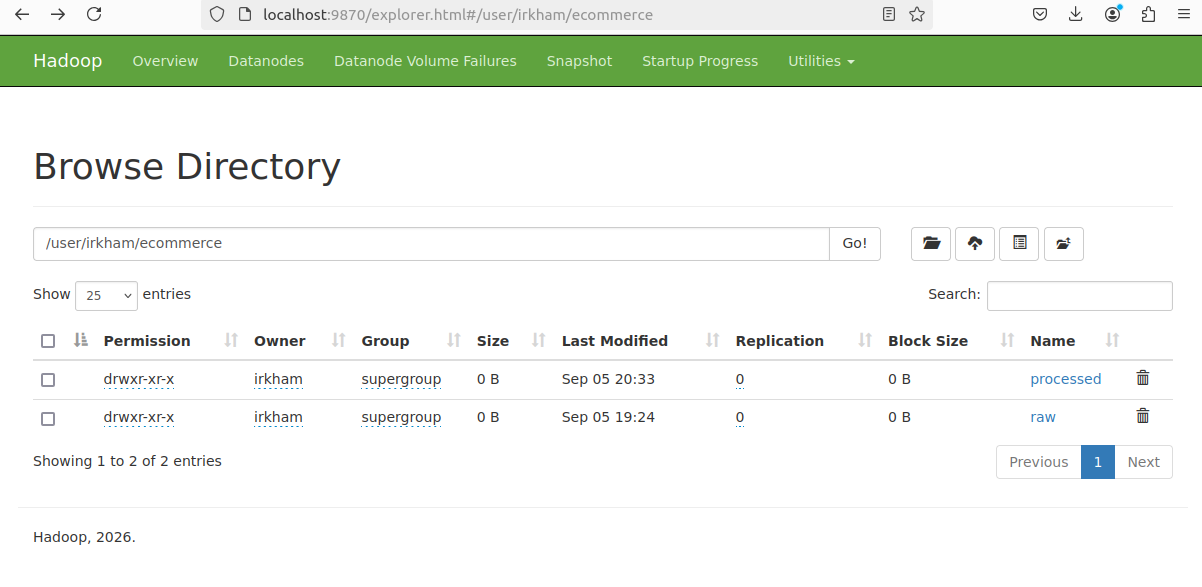

In [13]:
from IPython.display import Image
Image("HDFS_ui.png")

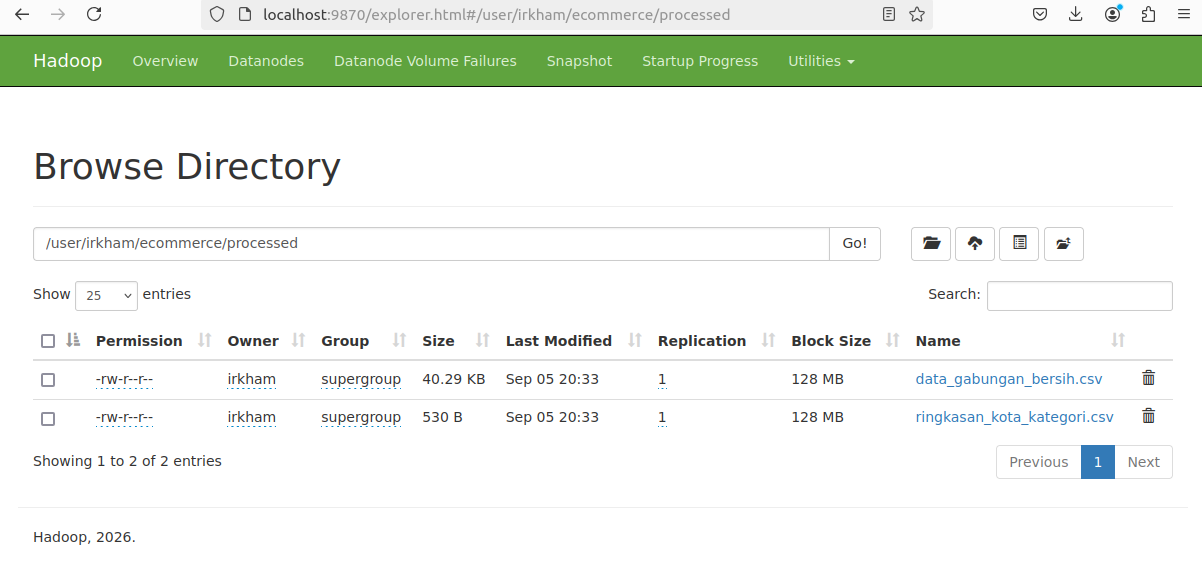

In [16]:
from IPython.display import Image
Image("HDFS_ui_prcessed.png")

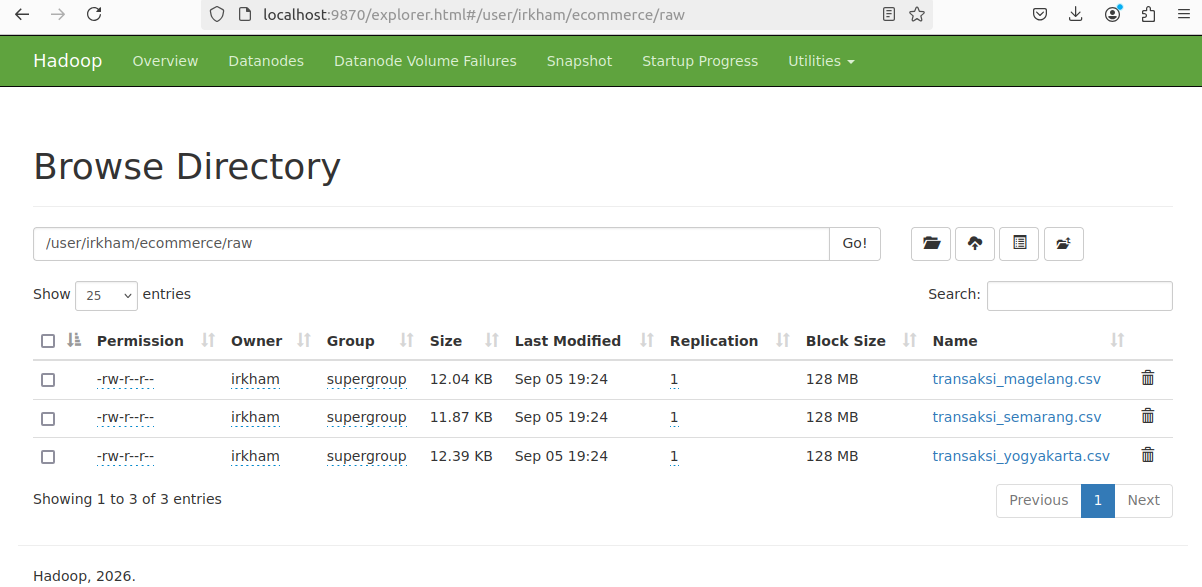

In [17]:
from IPython.display import Image
Image("HDFS_ui_raw.png")

In [ ]:
Apa keuntungan menyimpan data mentah(raw) terpisah dari data olahan(processed)di HDFS, bandingkan menyimpan semuanya bercampur dalam satu folder?

Jawab: Dengan menyimpan data mentah dan data olehan secara terpisah memiliki keuntungan
1.Menjaga keaslian data.Data mentah berisi data asli yang belum mengalami perubahan sehingga dapat digunakan lagi jika diperlukan untuk proses analisis atau pengolahan data.
    Data olahan berisi data yang sudag dibersihkan, diolah, digabungkan, dihitung sesuai keutuhan analisis.
2.Memudahkan tata kelola data.Dengan memisahkan kedua jenis data amak struktur penyimpanan jadi lebih rapi, mudah mengetahui lokasi data mentah dan data hasil olahan dan dipahami struktur datanya
3.Keamanan dan tata kelola data.Pemisahan data ini agar memudahkan penerapan hak akses data sehingga dapat mencegah penghapusan data yangtidak disengaja, pencurian data oleh pihak yang tidak bertanggung jawab pada data asli.
Pemisahan data raw dan processed di HDFS membuat penyimpanan data lebih rapi,mudah dikelola dan memudahkan penggunaan kembali data mentah untuk proses analisis selanjutnya